## 04 — Figure 1 Visualizations

**Purpose:** Generate publication Figure 1: UMAPs, cell type proportion stacked bar charts, statistical comparisons of lesional vs. non-lesional cell composition, and marker gene dot plots.

**Inputs:**
- `_data/obj_merged_71302cells_labeled.rds` — merged Seurat object (from notebook 03)
- `_data/sample_meta_2026.csv` — patient/sample metadata

**Outputs:**
- `_figures/Fig1_*.pdf` — all Figure 1 panels

**Run after:** `03_merge_datasets_label_cell_types.ipynb`

# Figure 1

In [1]:
set.seed(1)

source('./utils.R')

# Samples

In [2]:
obj = readRDS('../_data/obj_merged_71302cells_labeled.rds')

In [3]:
obj@meta.data$Type = ifelse(obj@meta.data$dataset == 'scRNA-seq', 'LesTx', obj@meta.data$Type)
sample_table = distinct(obj@meta.data %>% dplyr::select(PatientID, Type, TimePt)) %>% arrange(PatientID, TimePt)
rownames(sample_table) = NULL
sample_table %>% head(5)

,PatientID,Type,TimePt
,<chr>,<chr>,<chr>
1,P1,LesTx,Wk0
2,P1,LesUntx,Wk0
3,P1,NL,Wk0
4,P1,LesUntx,Wk24
5,P1,LesTx,Wk8


**Combine samples and plot**

In [4]:
sample_table[which(sample_table$Type == 'NL'), 'Type'] = 'Non-lesional'
sample_table[which(sample_table$Type == 'LesTx'), 'Type'] = 'Treated\nlesional'
sample_table[which(sample_table$Type == 'LesUntx'), 'Type'] = 'Untreated\nlesional'

sample_table$PatientID = factor(sample_table$PatientID, levels = paste0("P", 1:10))

agg_record_3fb32379cfde 
                      2

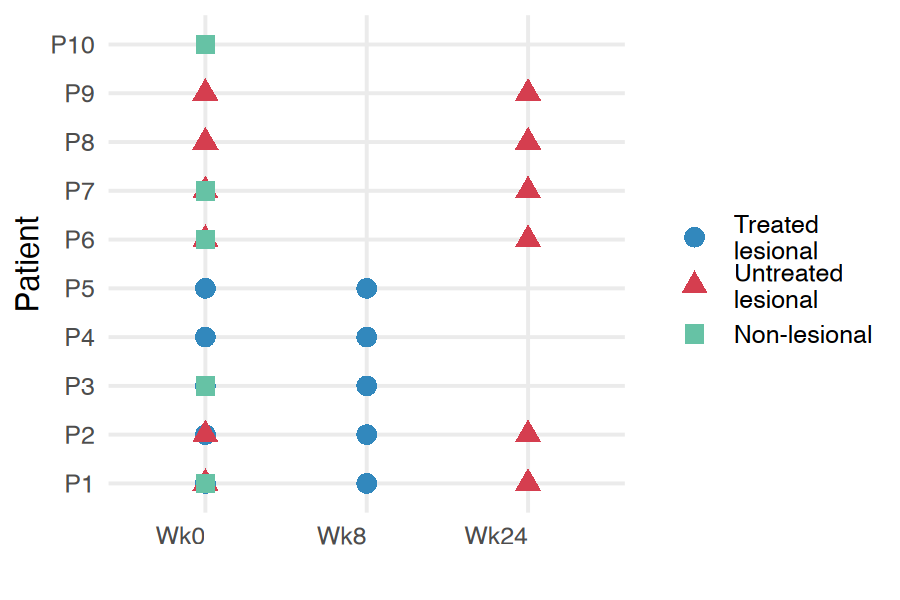

In [5]:
# Order the TimePt variable
sample_table$TimePt = factor(sample_table$TimePt, levels = c("Wk0", "Wk8", "Wk24"))
sample_table$Type = factor(sample_table$Type, levels = c("Treated\nlesional", "Untreated\nlesional", "Non-lesional"))

fig.size(3, 4.5)
pdf('../_figures/Fig1_samples.pdf', width = 4.5, height = 3)
# Plot the data
p = ggplot(sample_table, aes(x = TimePt, y = PatientID, color = Type, shape = Type)) +
    geom_point(size = 3) +
    labs( x = "", y = "Patient", col = '', shape = '') +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 0, hjust = 1)) + 
    scale_color_manual(values = color_scheme) + 
    theme(legend.position = 'right') + guides(col=guide_legend(ncol=1))
print(p)
dev.off()
p

# UMAP

In [6]:
obj@meta.data$cell_type = factor(obj@meta.data$cell_type, 
                                levels=c('Keratinocyte undiff.','Keratinocyte diff.', 
                                                           'Melanocyte', 'Hair follicle', 'Dermal adipocyte',
                                                           'Fibroblast', 'Pericyte', 'Vascular EC', 'Lymphatic EC',
                                                           'Mast', 'Myeloid', 'T cell'))
mydata = cbind(obj@meta.data, obj@reductions$umap@cell.embeddings)
levels(mydata$cell_type)
mydata$cell_type_num = as.numeric(mydata$cell_type)

[1] "Keratinocyte undiff." "Keratinocyte diff."   "Melanocyte"          
 [4] "Hair follicle"        "Dermal adipocyte"     "Fibroblast"          
 [7] "Pericyte"             "Vascular EC"          "Lymphatic EC"        
[10] "Mast"                 "Myeloid"              "T cell"

In [7]:
p = mydata %>% ggplot() +
    geom_point_rast(aes(x = umap_1, y = umap_2, col = cell_type)) +
    scale_color_manual(values = custom.colors) + theme_classic() + 
    guides(colour = guide_legend(override.aes = list(size=5))) + 
    labs(col = 'Cell Type')

# Extract the legend. Returns a gtable
leg <- get_legend(p)

fig.size(4, 2)
pdf('../_figures/Fig1_UMAP_merged_legend.pdf', width = 2, height = 4)
# Convert to a ggplot and print
as_ggplot(leg)
dev.off()

agg_record_3fb31043b24a 
                      2

In [8]:
# Calculate mean UMAP coordinates for each cell type
label_coords <- mydata %>%
  group_by(cell_type_num) %>%
  summarise(
    mean_UMAP_1 = mean(umap_1),
    mean_UMAP_2 = mean(umap_2)
)

In [9]:
mydata$dataset_label = ifelse(mydata$dataset == 'scRNA-seq', 'Treated lesional (scRNA-seq)', 
                              'Untreated lesional and Non-lesional (snRNA-seq)')

agg_record_3fb31df497a8 
                      2

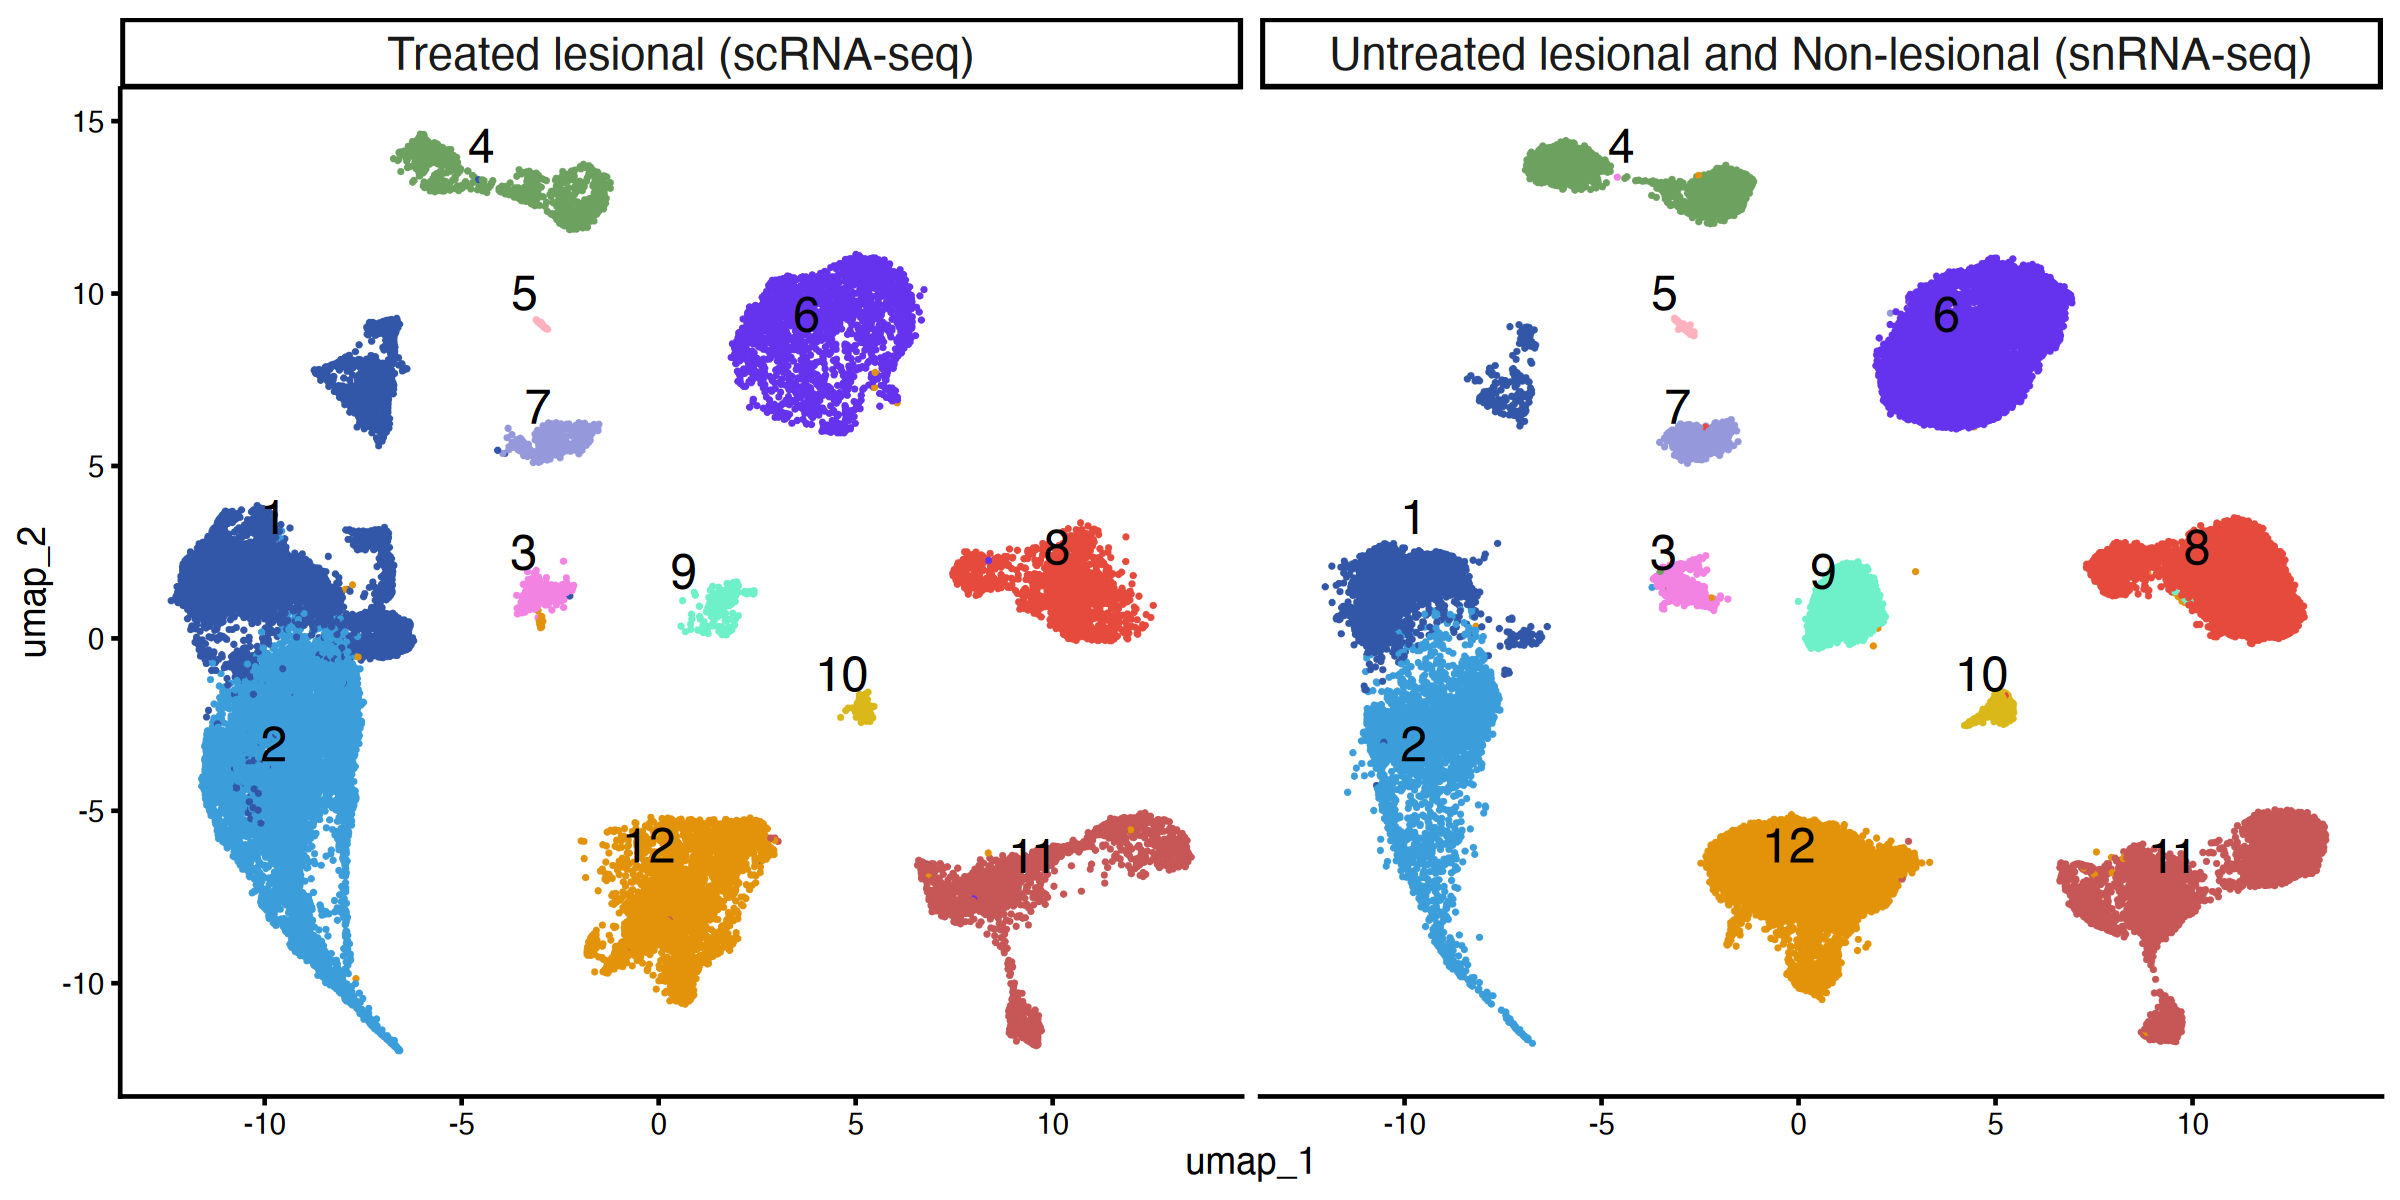

In [10]:
fig.size(6, 12)
pdf('../_figures/Fig1_UMAP_merged.pdf', width = 12, height = 6)
p = mydata %>% ggplot() +
    geom_point_rast(aes(x = umap_1, y = umap_2, col = cell_type), size = 0.2) +
    scale_color_manual(values = custom.colors) + theme_classic(base_size = 13) + 
    guides(colour = guide_legend(override.aes = list(size=3))) + theme(legend.position = 'none') +
    geom_text(data = label_coords, aes(x = mean_UMAP_1-0.5, y = mean_UMAP_2, label = cell_type_num),
            size = 6, fontface = "bold", color = "black", vjust = -0.5) + facet_wrap(~dataset_label) +
        theme(strip.text.x = element_text(size = 16))
print(p)
dev.off()
p

In [11]:
table(mydata$dataset)


scRNA-seq snRNA-seq 
    27448     43854 

# Cell Type Proportions

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Subject_TimePt, TimePt, and cell_type.
ℹ Output is grouped by Subject_TimePt and TimePt.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Subject_TimePt, TimePt, cell_type))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


agg_record_3fb3309004ea 
                      2

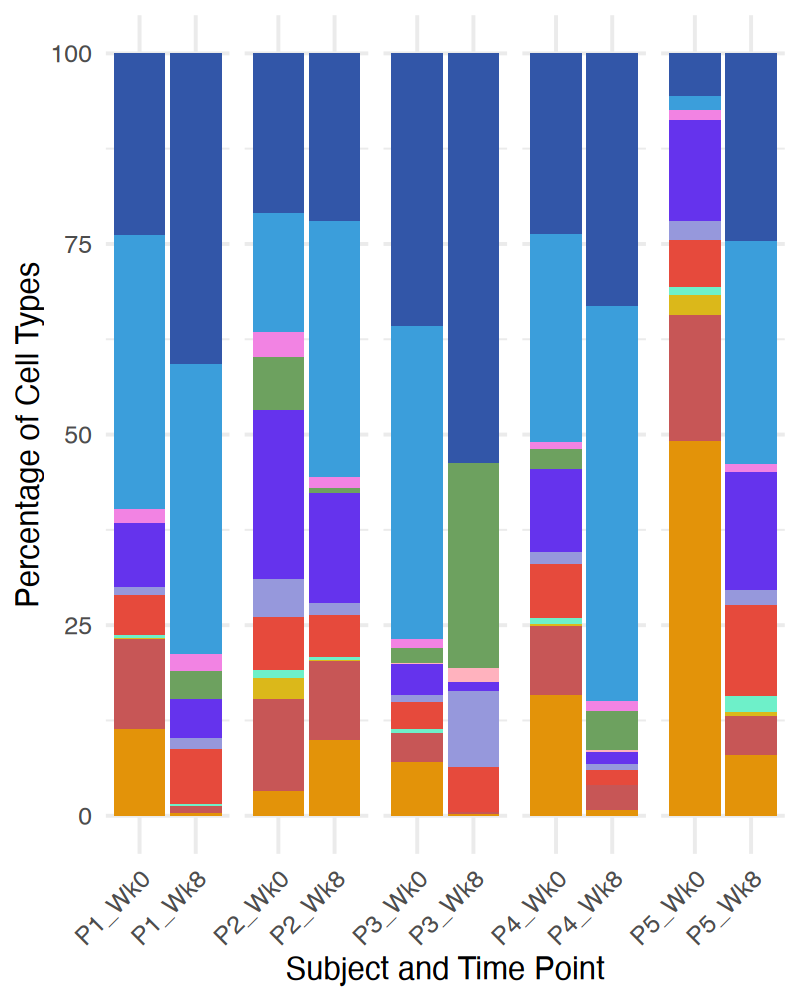

In [12]:
# Create a combined variable for Subject and TimePt
data <- mydata %>% filter(dataset == 'scRNA-seq') %>%
  mutate(Subject_TimePt = paste(PatientID, TimePt, sep = "_"))

# Summarize the data to get the percentage of each cell type per Subject+TimePt
data_summary1 <- data %>%
  group_by(Subject_TimePt, TimePt, cell_type) %>%
  summarise(cell_count = n()) %>%
  mutate(percent = (cell_count / sum(cell_count)) * 100) %>%
  mutate(Pair_Group = gsub("Wk8", "Wk", gsub("Wk0", "Wk", Subject_TimePt))) %>%
  mutate(Pair_Group = paste0('sc', Pair_Group)) %>%
  ungroup()

fig.size(5, 4)
# Create the stacked bar plot
p1 = ggplot(data_summary1, aes(x = Subject_TimePt, y = percent, fill = cell_type)) +
  geom_bar(stat = "identity") +
  labs(x = "Subject and Time Point", y = "Percentage of Cell Types") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_manual(values = custom.colors) + labs(fill = '') +
  facet_grid(. ~ Pair_Group, scales = "free_x", space = "free_x") +
  theme(strip.text.x = element_blank(), legend.position = 'none')

pdf('../_figures/Fig1_Proportions_by_Sample_scRNA.pdf', width = 4, height = 5)
print(p1)
dev.off()
p1

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Subject_TimePt, TimePt, Type, and cell_type.
ℹ Output is grouped by Subject_TimePt, TimePt, and Type.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Subject_TimePt, TimePt, Type, cell_type))` for per-operation grouping (`?dplyr::dplyr_by`)
  instead.


agg_record_3fb354d135a4 
                      2

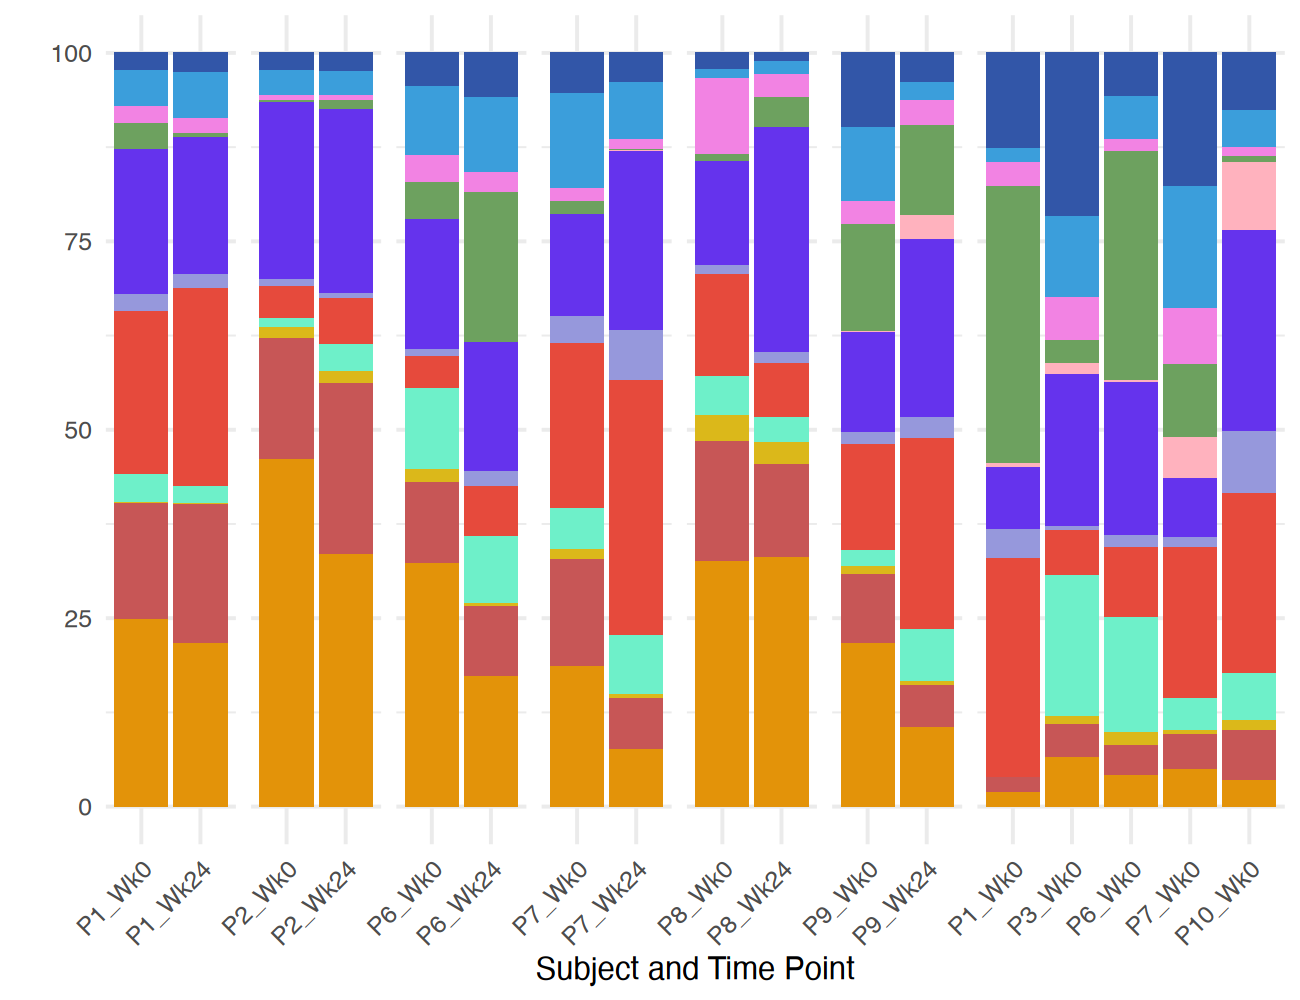

In [13]:
# Create a combined variable for Subject and TimePt
data <- mydata %>% filter(dataset == 'snRNA-seq') %>%
  mutate(Subject_TimePt = paste(PatientID, TimePt, sep = "_"))

data$Subject_TimePt = fct_relevel(data$Subject_TimePt, "P10_Wk0", after = Inf)

# Summarize the data to get the percentage of each cell type per Subject+TimePt
data_summary2 <- data %>% group_by(Subject_TimePt, TimePt, Type, cell_type) %>%
  summarise(cell_count = n()) %>%
  mutate(percent = (cell_count / sum(cell_count)) * 100) %>%
  mutate(Pair_Group = ifelse(Type == 'LesUntx', gsub("Wk24", "Wk", gsub("Wk0", "Wk", Subject_TimePt)), 'z')) %>%
  mutate(Pair_Group = paste0('sn', Pair_Group)) %>%
  ungroup()

fig.size(5, 6.5)
# Create the stacked bar plot
p2 = ggplot(data_summary2, aes(x = Subject_TimePt, y = percent, fill = cell_type)) +
  geom_bar(stat = "identity") +
  labs(x = "Subject and Time Point", y = "") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_manual(values = custom.colors) + labs(fill = '') +
  facet_grid(. ~ Pair_Group, scales = "free_x", space = "free_x") +
  theme(strip.text.x = element_blank(), legend.position = 'none')

pdf('../_figures/Fig1_Proportions_by_Sample_snRNA.pdf', width = 6.5, height = 5)
print(p2)
dev.off()
p2

agg_record_3fb32f89dea3 
                      2

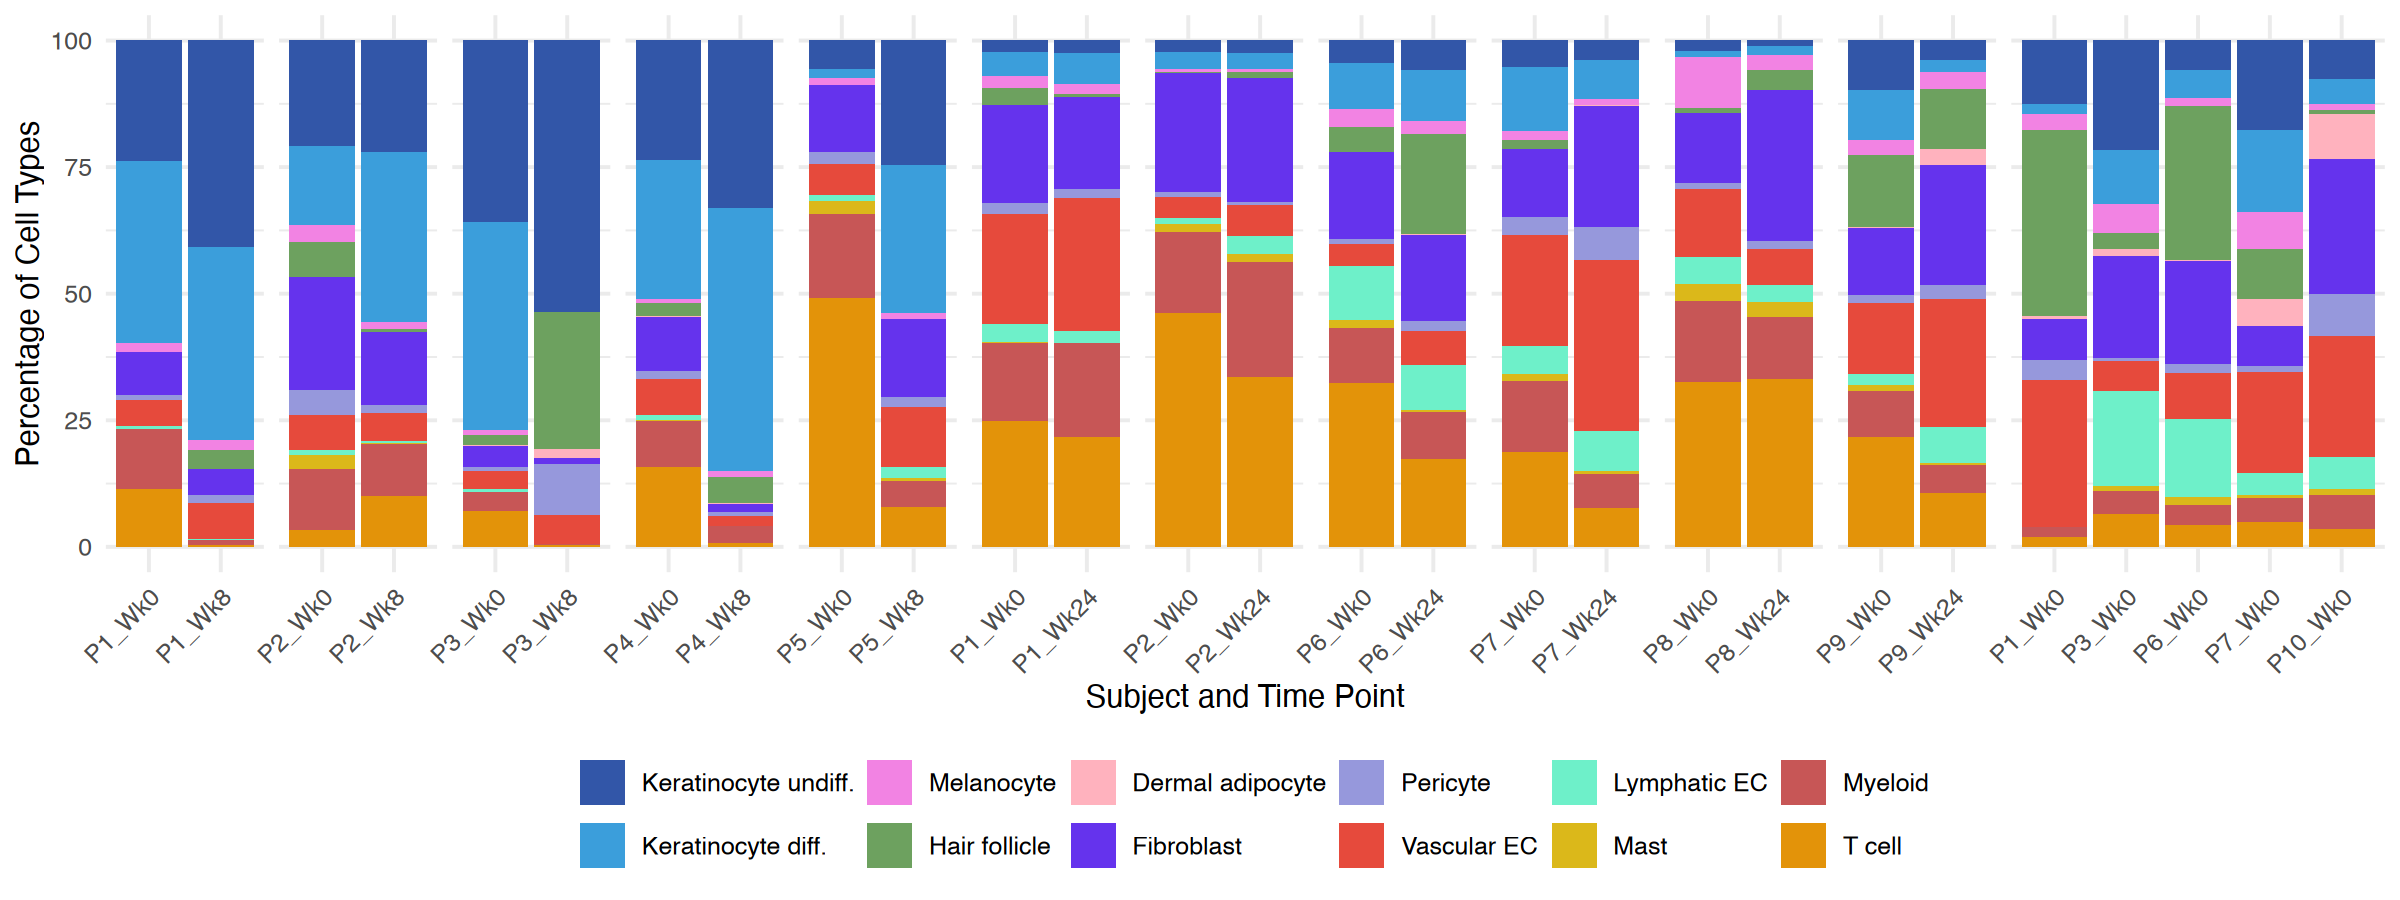

In [14]:
fig.size(4.5, 12)
# Create the stacked bar plot
data_summary2$Type = NULL
combined_data = rbind(data_summary1, data_summary2)
combined_data$Subject_TimePt = fct_relevel(combined_data$Subject_TimePt, "P10_Wk0", after = Inf)

p2 = ggplot(combined_data, aes(x = Subject_TimePt, y = percent, fill = cell_type)) +
  geom_bar(stat = "identity") +
  labs(x = "Subject and Time Point", y = "Percentage of Cell Types") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_manual(values = custom.colors) + labs(fill = '') +
  facet_grid(. ~ Pair_Group, scales = "free_x", space = "free_x") +
  theme(strip.text.x = element_blank(), legend.position = 'bottom') + 
    guides(fill = guide_legend(ncol = 6))

pdf('../_figures/Fig1_Proportions_by_Sample_merged.pdf', width = 12, height = 4.5)
print(p2)
dev.off()
p2

# Baseline Cell Type Proportions

In [15]:
df = data_summary2 %>% filter(TimePt == 'Wk0')
res = NULL
for (ct in unique(df$cell_type)) {
    df_ct = df %>% filter(cell_type == ct)
    NL = df_ct %>% filter(Pair_Group == 'snz')
    LesUntx = df_ct %>% filter(Pair_Group != 'snz')
    w = wilcox.test(NL$percent, LesUntx$percent)
    myres = data.frame(cell_type = ct, NL_avg_pct = mean(NL$percent), LesUntx_avg_pct = mean(LesUntx$percent),
                       p_val = w$p.value)
    res = rbind(res, myres)
}

In [16]:
res$p_val_adj = p.adjust(res$p_val, method = 'fdr')
res

cell_type,NL_avg_pct,LesUntx_avg_pct,p_val,p_val_adj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Keratinocyte undiff.,13.138208,4.44042907,0.017316017,0.06926407
Keratinocyte diff.,7.835842,6.80576205,0.662337662,0.79480519
Melanocyte,3.839302,3.53971306,0.930735931,0.93073593
Hair follicle,16.137597,4.26524890,0.329004329,0.65800866
Fibroblast,16.668779,16.79546352,0.930735931,0.93073593
Pericyte,3.074344,1.71882906,0.662337662,0.79480519
Vascular EC,17.612617,13.27686804,0.428571429,0.73469388
Lymphatic EC,11.175634,4.73470555,0.114285714,0.27428571
Mast,1.140712,1.51401826,0.609523810,0.79480519


In [17]:
# First calculate statistics for each cell type
stat_tests <- df %>%
  mutate(Group = ifelse(Pair_Group == 'snz', 'NL', 'LesUntx')) %>%
  group_by(cell_type) %>%
  wilcox_test(percent ~ Group) %>%
  adjust_pvalue(method = "fdr") %>%
  add_significance()

In [18]:
anndata = data.frame(cell_type = unique(df$cell_type), x = 1.5, y = 40)
anndata$label = ifelse(anndata$cell_type %in% c("Myeloid", "T cell"), "*", "ns")
anndata$color = ifelse(anndata$cell_type %in% c("Myeloid", "T cell"), "red", "black")

agg_record_3fb351746ec4 
                      2

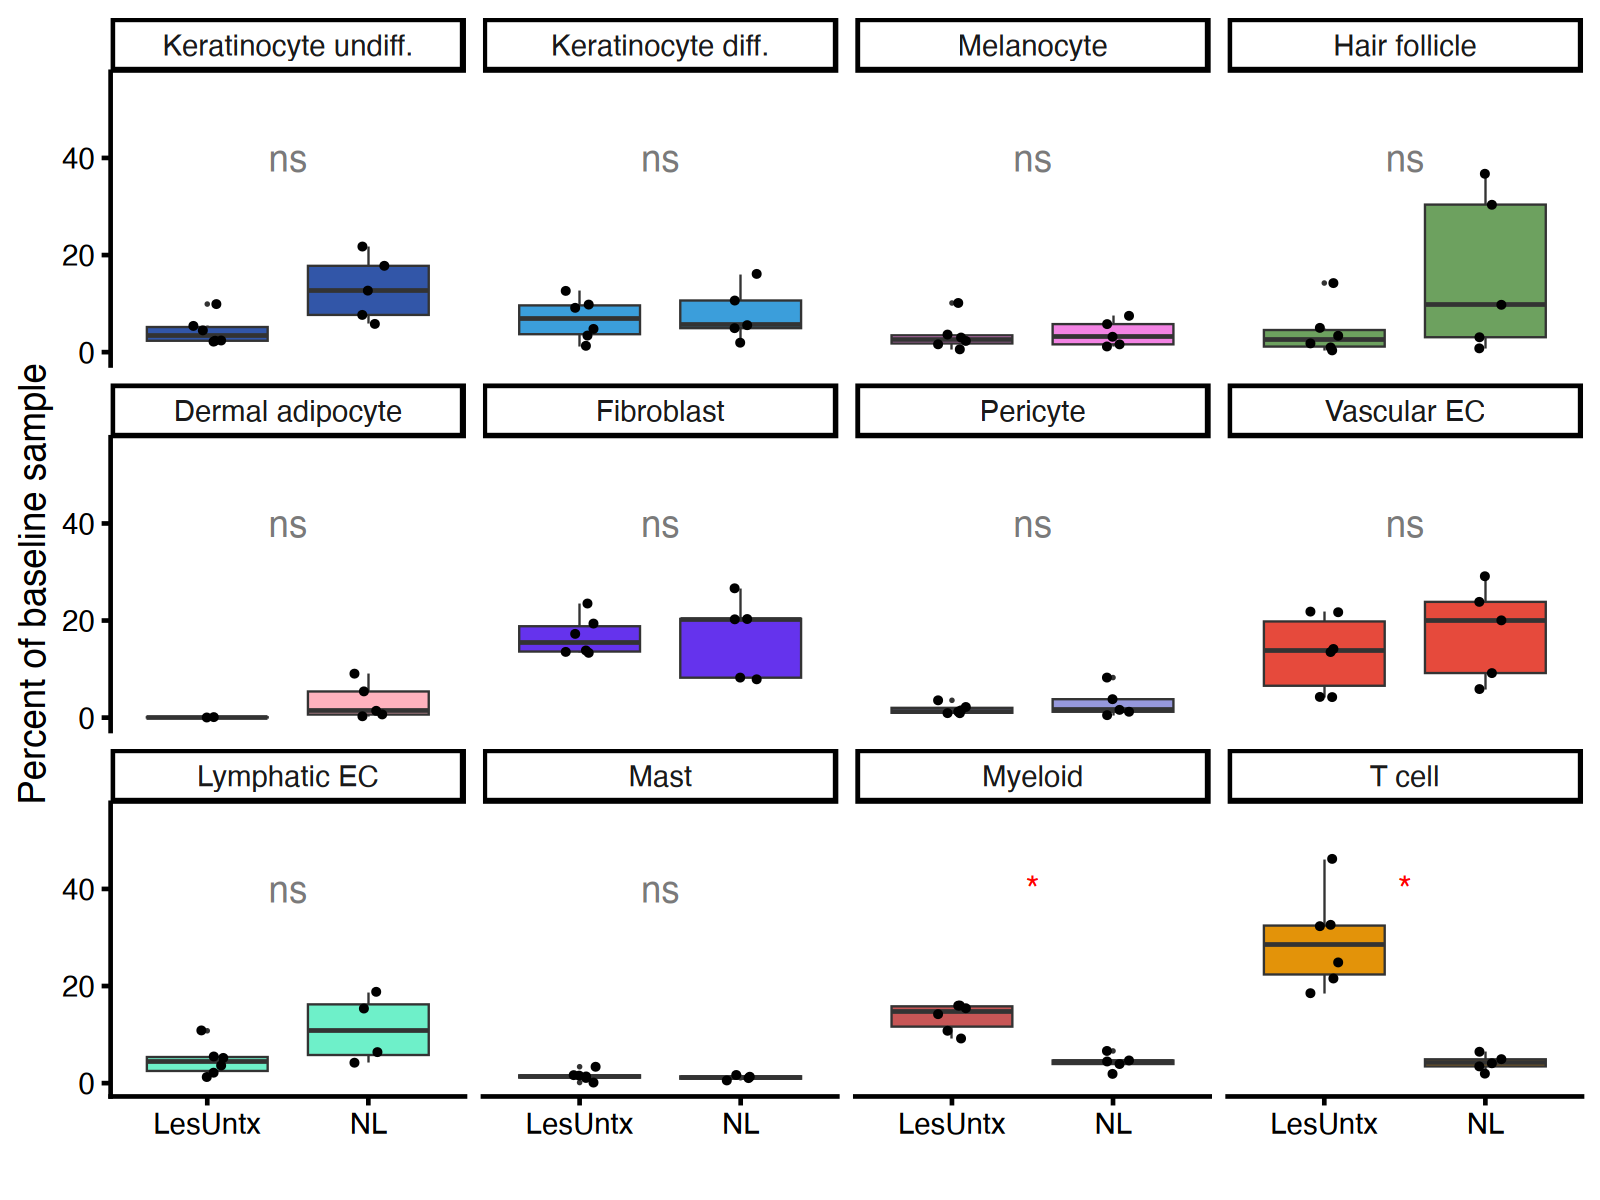

In [21]:
fig.size(6, 8)
p = df %>% mutate(Group = ifelse(Pair_Group == 'snz', 'NL', 'LesUntx')) %>%
        ggplot() +
        geom_boxplot(aes(x = Group, y = percent, fill = cell_type), outlier.size = 0, lwd = 0.3) +
        geom_jitter(aes(x = Group, y = percent, fill = cell_type), width = 0.1, size = 0.6) +
        facet_wrap(~cell_type) + theme_classic(base_size = 13) +
        scale_fill_manual(values = custom.colors) + ylab('Percent of baseline sample') + xlab('') +
        ylim(0, 55) + theme(legend.position = 'none') +
        geom_text(data = anndata, aes(x = x, y = y, label = label,
                                      color = ifelse(cell_type %in% c("Myeloid", "T cell"), "red", "grey48"))) +
        scale_color_identity()
pdf('../_figures/Fig1_Prop_StatTests.pdf', height = 6, width = 8)
print(p)
dev.off()
p

# Heatmap + Dot Plot

In [22]:
Idents(obj) = factor(Idents(obj), levels = c('Keratinocyte undiff.','Keratinocyte diff.', 
                                                           'Melanocyte', 'Hair follicle', 'Dermal adipocyte',
                                                           'Fibroblast', 'Pericyte', 'Vascular EC', 'Lymphatic EC',
                                                           'Mast', 'Myeloid', 'T cell'))

In [23]:
markers = c("KRT5", "KRT14", "KRT1", "KRT10", "MLANA", "BCAN", "DCT", "KRT15", "KRT19", 
            "PLIN1", "FABP4", "LPL", "PDGFRA", "LUM", "COL6A1", "COL1A2", "ACTA2", "MYH11", 
            "CDH5", "SELE", "SOX17", "VWF", "PROX1", "LYVE1", "KIT", "MS4A2", "HDC", "LYZ", 
            "AIF1", "CD68", "CD83", "LCK", "CD3E", "CD3D", "CD3G")

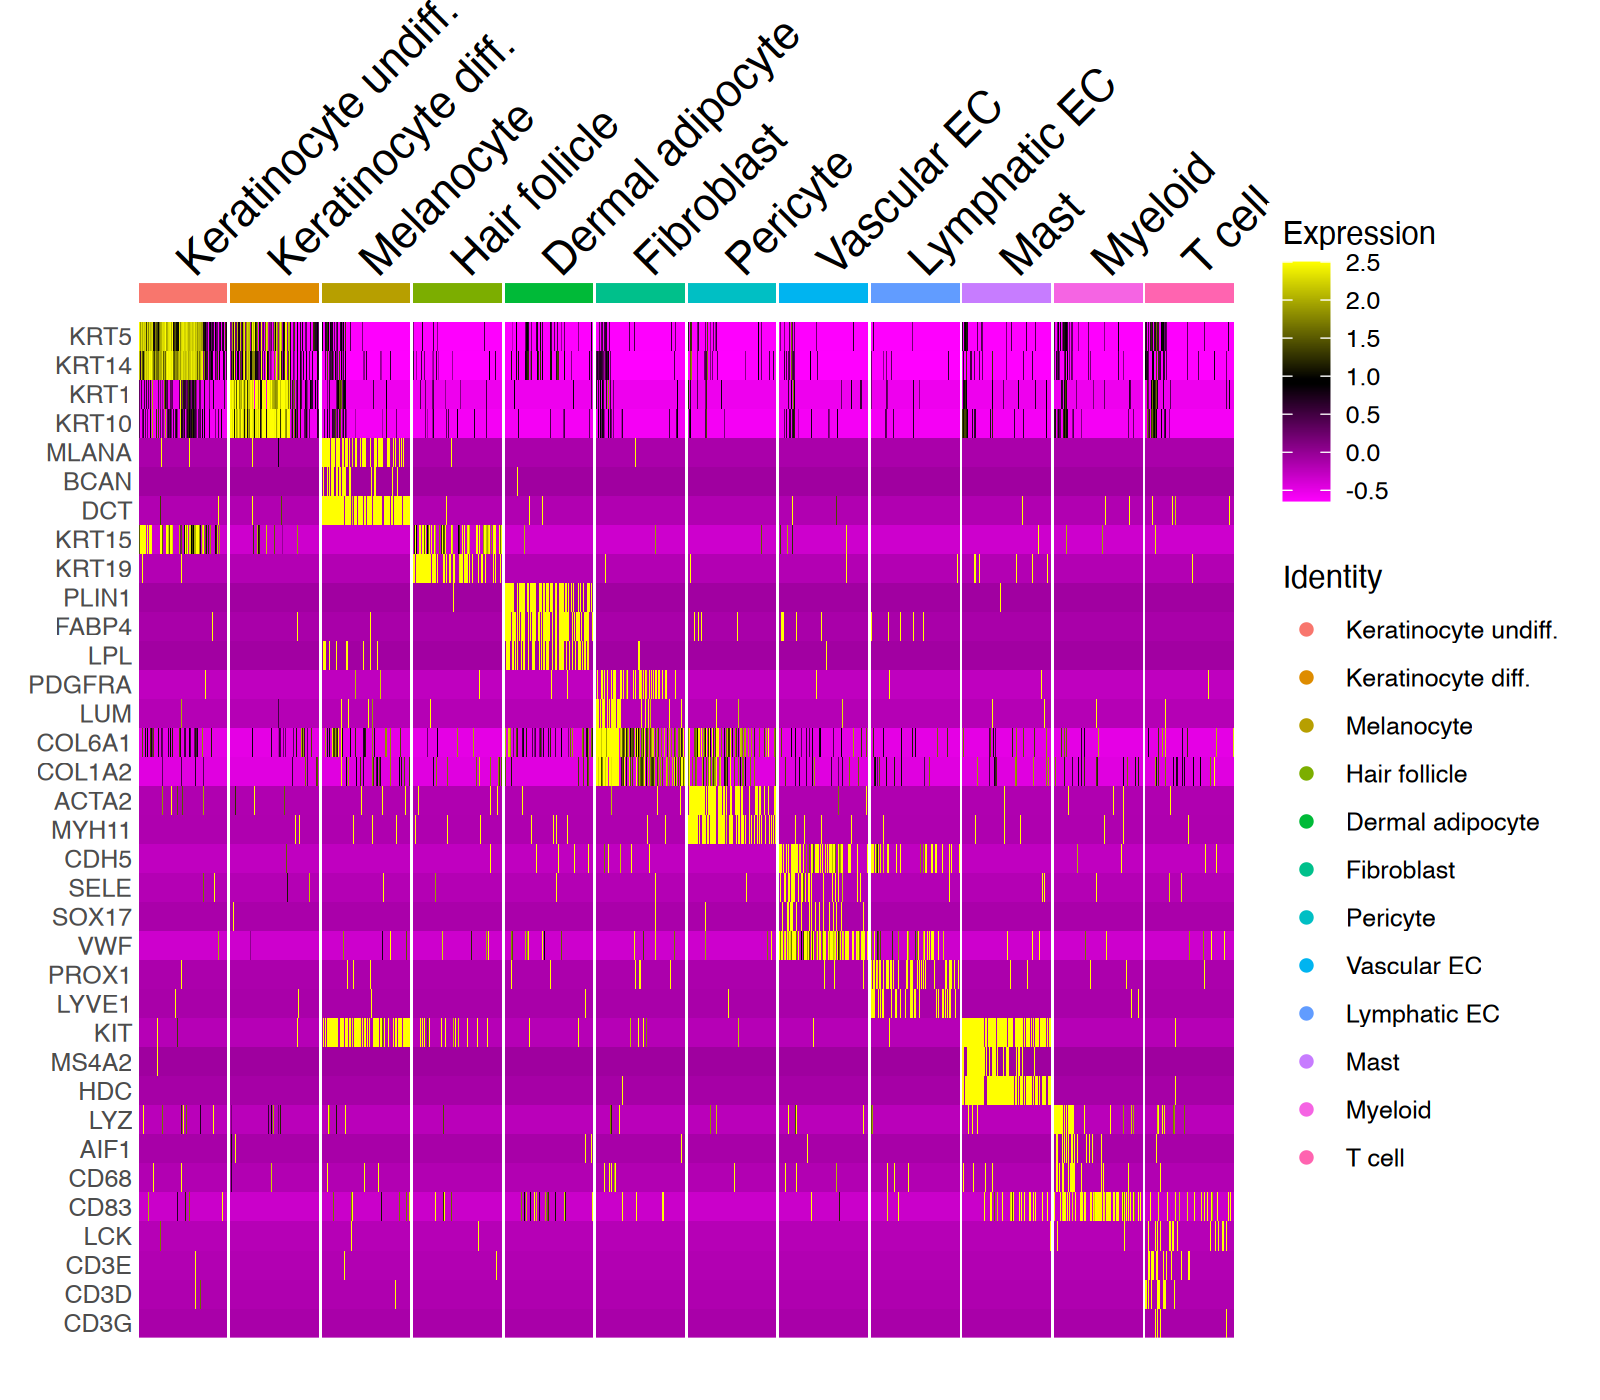

In [24]:
fig.size(7, 8)
DoHeatmap(subset(obj, downsample = 100), features = markers)

agg_record_3fb369483687 
                      2

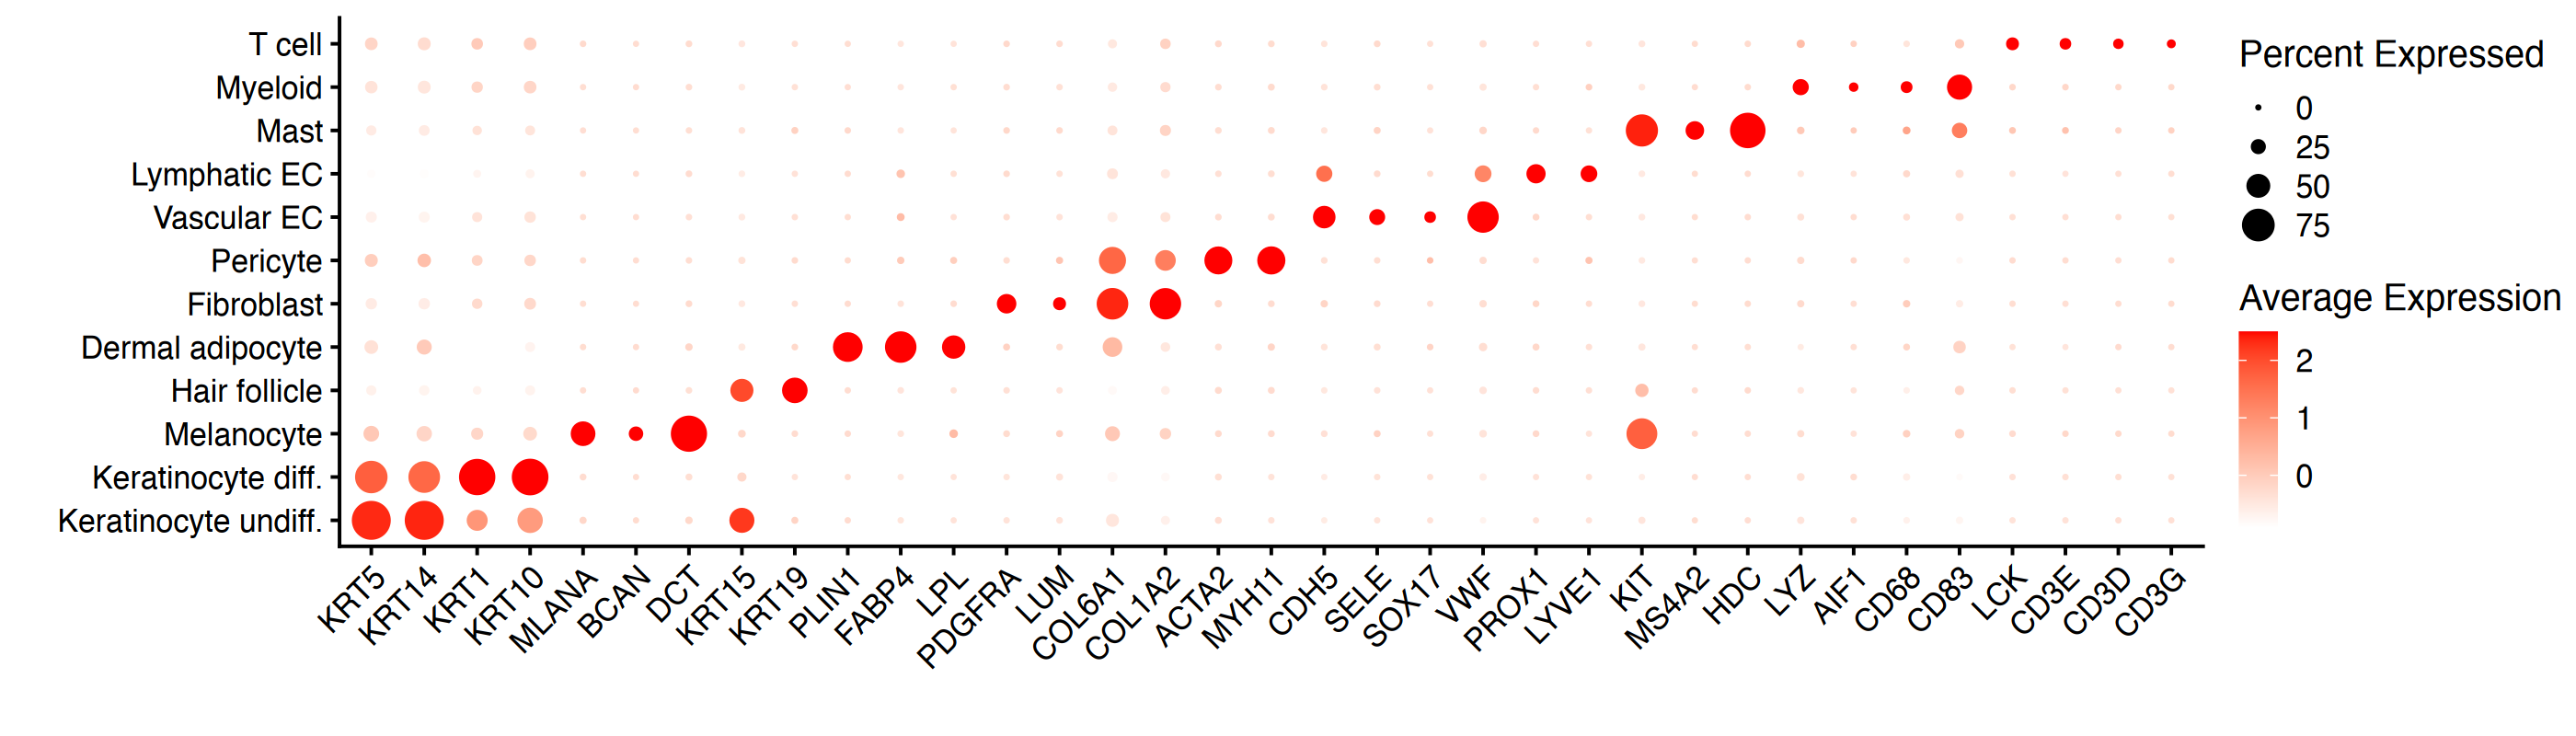

In [25]:
fig.size(4, 14)
d = DotPlot(obj, assay = "RNA", features = markers, cols = c("white", "red")) + RotatedAxis() + labs(y = '', x = '')

pdf('../_figures/Fig1_dotPlot.pdf', width = 14, height = 4)
print(d)
dev.off()
d

In [26]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: aarch64-apple-darwin20.0.0
Running under: macOS Sonoma 14.6

Matrix products: default
BLAS/LAPACK: /opt/anaconda3/envs/resiq/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] org.Hs.eg.db_3.20.0         AnnotationDbi_1.68.0       
 [3] msigdbr_26.1.0              clusterProfiler_4.14.0     
 [5] rlang_1.2.0                 scales_1.4.0               
 [7] patchwork_1.3.2             RColorBrewer_1.1-3         
 [9] rstatix_0.7.3               mixtools_2.0.0.1           
[11] limma_3.62.2                cowplot_1.2.0              
[13] ggrastr_1.0.2               ggpubr_0.6.3               
[15] lme4_2.0-1                  singlecellmethods_0.1.0    
[17] MAST_1.32.0           